# Etude 1: Régression linéaire simple -> 2h max

Référénce: https://oraprdnt.uqtr.uquebec.ca/Gscdepot/paf1010/19/M13.pdf

Importer les librairies : numpy, pandas, matplolib,...

In [25]:
# linear algebra
import numpy as np 

# data processing
import pandas as pd 

# data visualization
import seaborn as sns
%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import style

## Partie 1 - Une première base de données  


### Importation de données et analyse exploratoire

1) Lire le fichier U_I.csv sous forme tableau de données utilisant pandas et afficher les 5 premières lignes du tableau

In [26]:
df = pd.read_csv('dataset1.csv',sep=';')
n=5
df.head(n) # affiche les n premières lignes par défaut (5 par défaut)

,x,y
0,0,46.357215
1,1,46.080189
2,2,45.077372
3,3,48.480649
4,4,43.666733


2) Afficher un résumé concis du DataFrame pour comprendre les données (les colonnes, nombre d'éléments non nuls, types de données) 

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       26 non-null     int64  
 1   y       26 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 548.0 bytes


3) Produire des statistiques descriptives du dataset (max, min, mean, etc.) 

In [28]:
df.describe()

,x,y
count,26.000000,26.000000
mean,12.500000,27.604172
std,7.648529,12.549125
min,0.000000,6.242566
25%,6.250000,17.853984
50%,12.500000,27.263529
75%,18.750000,35.945827
max,25.000000,48.480649


4. Tracer y(x), sous forme de nuage de points

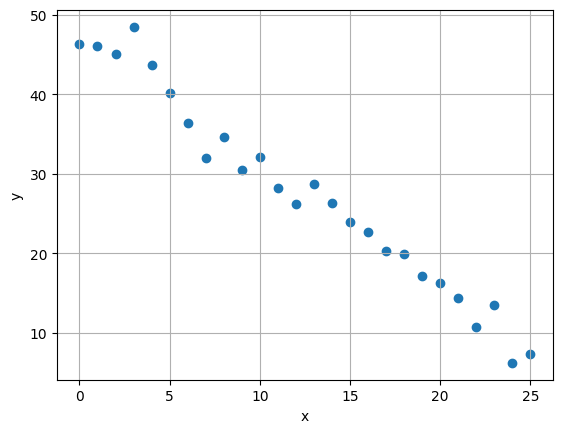

In [29]:
plt.scatter(df.x,df.y)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

5. Justifier le choix du modèle de régression linéaire simple pour la prédiction

Votre réponse: ça ressemble bien à une droite !

### Construction du modèle de régression linéaire simple

6. Identifier la variable indépendante (nommée 'x') et celle dépendante (nommée 'y') dans le dataset. Faire ensuite une extraction pour avoir les deux variables x et y respectives

In [30]:
x = df.x
y = df.y

Pour construire le modèle RL (régression linéaire) simple y = w0 + w1*x, il nous faut déterminer les coefficients 
* w0: ordonnée à l'origine (ou intercept en anglais)
* w1: coefficient directeur/pente (ou slope en anglais)
Nous procédons à la méthode des moindres carrés ordinaire (ou ordinary least squares (OLS) en anglais)

Référence: https://perso.lpsm.paris/~aguyader/files/teaching/Regression.pdf

7. Compléter le code suivant (OLS function)

In [ ]:
def compute_coefficient(x, y):
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator = 0
    denominator = 0

    for i in range(n):
        numerator += (x[i] - x_mean) * (y[i] - y_mean)
        denominator += (x[i] - x_mean) ** 2

    # Calculate coefficients
    slope = numerator / denominator
    intercept = y_mean - slope * x_mean

    return slope, intercept

8) Phase d'entrainement (training)

Il s'agit de déterminer les coefficients w0 et w1 à partir du dataset

In [50]:
slope_ols, intercept_ols = compute_coefficient(x,y)

In [51]:
slope_ols, intercept_ols

(np.float64(-1.6188168394132638), np.float64(47.839382220563934))

Il existe la fonction "LinearRegression" dans la bibliothèque ScikitLearn https://scikit-learn.org/stable/ qui fait la même chose

https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html

9. Entrainement par le modèle RL dans ScikitLearn

Commenter le code suivant en expliquant ce que chaque ligne de code fait.

Faire tourner le code et le corriger s'il ne marche pas

In [34]:
from sklearn.linear_model import LinearRegression

model_RL = LinearRegression() 

# correction- debut
x_reshape = x.values.reshape(-1, 1)
y_reshape = y.values.reshape(-1, 1)

# correction- fin

model_RL.fit(x_reshape,y_reshape) # entraîne le modèle

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


10. Afficher les coefficients w0 et w1 et comparer avec ceux obtenus de la question 8.

In [35]:
pente = model_RL.coef_[0][0]
coeff_intercept = model_RL.intercept_[0]
print('pente = ',pente)
print('coeff_intercept = ',coeff_intercept)

pente =  -1.6188168394132625
coeff_intercept =  47.83938222056392


#### Remarque importante: 
Avant de développer vos propres fonctions en Machine Learning, prenez l'habitude de **rechercher des solutions existantes**. Ces dernières sont souvent le fruit du travail d'experts, optimisées et robustes grâce aux retours d'expérience de la communauté. Cela vous permettra de gagner du temps, d'éviter les erreurs courantes et de bénéficier de code de qualité. La question 7 a pour objectif principal d'illustrer de manière pédagogique le processus d'entraînement d'un modèle.

### Prédiction à l'aide du modèle RL entrainé

11. Utiliser le modèle model_RL pour faire la prédiction: 
* L'entrée (input): x
* La sortie (output): nommée ypred

In [36]:
ypred = model_RL.predict(x_reshape)


12. Donner la définition et ensuite déterminer le score, les erreurs MSE, RMSE, MAE, MAPE du modèle model_RL

Définitions:
Score:

MSE  ("mean square error" = moindres carrés)

RMSE ("root mean square error" = moindres carrés avec racine = norme euclidienne)

MAE ("mean absolute error" = moyenne valeurs absolue = norme 1)

MAPE ("mean absolute percentage error" = moyenne valeurs absolue en pourcentage : $\frac{|y-\hat{y}|}{|y|}$)

In [37]:
# déterminer les erreurs
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calcul du MSE (Mean Squared Error)
mse = mean_squared_error(y_reshape, ypred)
print(f"MSE (Mean Squared Error) : {mse}")

# Calcul du RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)
print(f"RMSE (Root Mean Squared Error) : {rmse}")

# Calcul du MAE (Mean Absolute Error)
mae = mean_absolute_error(y_reshape, ypred)
print(f"MAE (Mean Absolute Error) : {mae}")

# Calcul du MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_reshape - ypred) / y_reshape)) * 100
print(f"MAPE (Mean Absolute Percentage Error) : {mape}%")

MSE (Mean Squared Error) : 4.016645385459095
RMSE (Root Mean Squared Error) : 2.0041570261481745
MAE (Mean Absolute Error) : 1.4723738901899353
MAPE (Mean Absolute Percentage Error) : 6.858461116855029%


Commenter sur la précision du modèle et le choix initial de ce modèle RL

Votre réponse: c'est pas mal, c'est adapté.

13. Tracer le nuage des points des données et tracer la droite donnée par le modèle

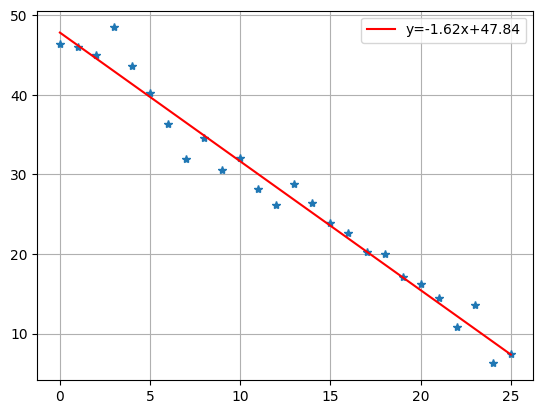

In [38]:
plt.plot(df['x'],df['y'],'*')

x1 = np.linspace(0,25,40)
y1 = pente*x1+coeff_intercept
#plt.plot(x1, y1, '-r', label='y={0}x+{1}'.format(round(pente,2),round(coeff_intercept,2)))
plt.plot(x1, y1, '-r', label=f'y={pente:.2f}x+{coeff_intercept:.2f}')
plt.legend(loc='best')
plt.grid()
plt.show()

14. Estimer y pour x=20.5.  

In [39]:
x_new = [[20.5]]   # crochet car doit être 2D
y_pred_new = model_RL.predict(x_new)
print((x_new[0][0],y_pred_new[0][0]))

(20.5, np.float64(14.653637012592036))


15. Mettre ce point sur le graphique précédent

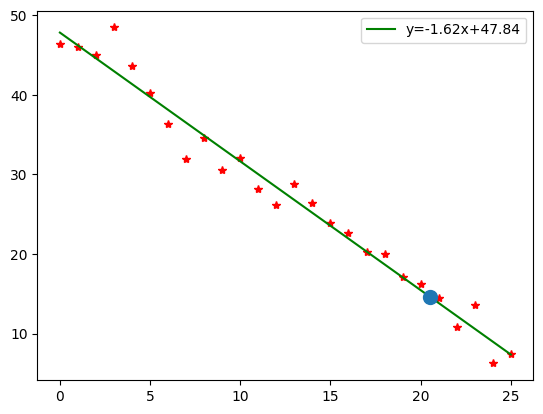

In [40]:
plt.plot(df['x'],df['y'],'*r')

x1 = np.linspace(0,25,40)
y1 = pente*x1+coeff_intercept
plt.plot(x1, y1, '-g', label='y={0}x+{1}'.format(round(pente,2),round(coeff_intercept,2)))

plt.plot(x_new[0][0], y_pred_new[0], marker="o", markersize=10)

plt.legend(loc='best')
plt.show()

#### Remarque importante: 
Ce nouveau point de données est particulièrement intéressant car il n'est pas représenté dans l'ensemble d'entraînement. Une prédiction sur ce point nous permettra d'évaluer de manière plus fine la capacité du modèle à généraliser à des situations inédites.

16. Peut-on évaluer la précision de prédiction pour ce nouveau point? 

Votre réponse: non on n'a pas la vraie valeur par définition

17. Votre solution pour évaluer la capacité du modèle à généraliser à des situations inédites?

Votre réponse: train / test

## Partie 2 - Une autre base de données - séparation train/test  

18. Importer "dataset.csv" et faire des analyses exploratoires comme dans la partie 1

In [41]:
df2 = pd.read_csv('dataset2.csv')
print(df2.shape)
df2.head()

(237, 4)


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [42]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Gender               237 non-null    int64
 1   Age Range            237 non-null    int64
 2   Head Size(cm^3)      237 non-null    int64
 3   Brain Weight(grams)  237 non-null    int64
dtypes: int64(4)
memory usage: 7.5 KB


In [43]:
df2.describe()

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
count,237.000000,237.000000,237.000000,237.000000
mean,1.434599,1.535865,3633.991561,1282.873418
std,0.496753,0.499768,365.261422,120.340446
min,1.000000,1.000000,2720.000000,955.000000
25%,1.000000,1.000000,3389.000000,1207.000000
50%,1.000000,2.000000,3614.000000,1280.000000
75%,2.000000,2.000000,3876.000000,1350.000000
max,2.000000,2.000000,4747.000000,1635.000000


19. Peut-on utiliser le modèle RL simple pour prédire "brain weight" à partir de "head size" ? Justifier

Votre réponse:

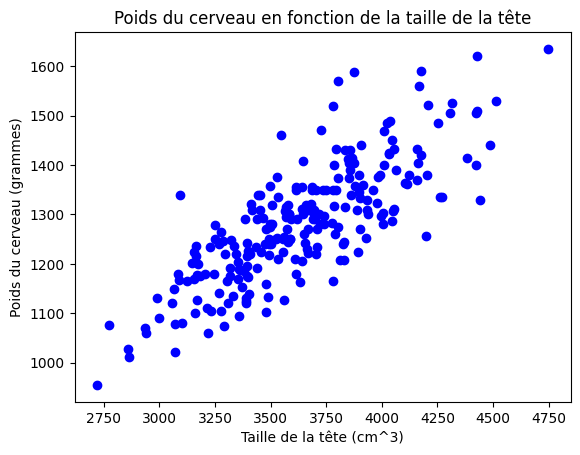

In [44]:
# Tracer le nuage de points
plt.scatter(df2['Head Size(cm^3)'], df2['Brain Weight(grams)'], color='blue')

# Ajouter des labels
plt.title("Poids du cerveau en fonction de la taille de la tête")
plt.xlabel("Taille de la tête (cm^3)")
plt.ylabel("Poids du cerveau (grammes)")

# Afficher le graphique
plt.show()

20. Construire un modèle RL en utilisant SkicitLearn

In [45]:
# votre code
from sklearn.linear_model import LinearRegression

model_RL2 = LinearRegression() 



In [46]:
# Définir les variables indépendantes (X) et dépendantes (y)
X2 = df2['Head Size(cm^3)']  # Variables indépendantes
y2 = df2['Brain Weight(grams)']  # Variable dépendante

21. Entrainer ce modèle sur différentes partitions train/test en utilisant les ratios suivants:
* 20% train/ 80% test
* 50% train/ 50% test
* 80% train/ 20% test

Les partitions seront créées en respectant l'ordre d'apparition des données dans l'ensemble.

Pour chaque partition, afficher les métriques: score, MSE, RMSE, MAE, MAPE pour train et puis pour test

Comparer et Commenter les résultats

In [47]:
# votre code
# Fonction pour calculer le MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# List des partitions de train et test
partitions = [(0.2, 0.8), (0.5, 0.5), (0.8, 0.2)]

for train_size, test_size in partitions:
    # Créer les ensembles train/test selon le ratio
    train_end = int(len(X2) * train_size)
    X_train, X_test = X2[:train_end], X2[train_end:]
    y_train, y_test = y2[:train_end], y2[train_end:]
    X_train = X_train.values.reshape(-1, 1)
    X_test = X_test.values.reshape(-1, 1)

    # Initialiser le modèle de régression linéaire multiple
    model_RL2 = LinearRegression() 


    # Entraîner le modèle sur les données d'entraînement
    model_RL2.fit(X_train, y_train)

    # Prédictions sur l'ensemble d'entraînement
    y_train_pred = model_RL2.predict(X_train)
    
    # Prédictions sur l'ensemble de test
    y_test_pred = model_RL2.predict(X_test)

    # Calcul des métriques pour l'ensemble d'entraînement
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # Calcul des métriques pour l'ensemble de test
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Affichage des résultats
    print(f"\nPartition train/test: {int(train_size*100)}% train / {int(test_size*100)}% test")
    
    # Résultats pour l'ensemble d'entraînement
    print(f"Ensemble d'entraînement - R2 : {train_r2:.3f}, MSE : {train_mse:.3f}, RMSE : {train_rmse:.3f}, MAE : {train_mae:.3f}, MAPE : {train_mape:.3f}%")
    
    # Résultats pour l'ensemble de test
    print(f"Ensemble de test - R2 : {test_r2:.3f}, MSE : {test_mse:.3f}, RMSE : {test_rmse:.3f}, MAE : {test_mae:.3f}, MAPE : {test_mape:.3f}%")


Partition train/test: 20% train / 80% test
Ensemble d'entraînement - R2 : 0.449, MSE : 5538.651, RMSE : 74.422, MAE : 58.643, MAPE : 4.270%
Ensemble de test - R2 : 0.343, MSE : 8354.853, RMSE : 91.405, MAE : 75.028, MAPE : 6.195%

Partition train/test: 50% train / 50% test
Ensemble d'entraînement - R2 : 0.520, MSE : 5753.928, RMSE : 75.855, MAE : 58.738, MAPE : 4.384%
Ensemble de test - R2 : 0.527, MSE : 5165.683, RMSE : 71.873, MAE : 57.769, MAPE : 4.806%

Partition train/test: 80% train / 20% test
Ensemble d'entraînement - R2 : 0.573, MSE : 5593.061, RMSE : 74.787, MAE : 58.348, MAPE : 4.468%
Ensemble de test - R2 : 0.649, MSE : 3880.492, RMSE : 62.294, MAE : 49.994, MAPE : 4.278%


Afin d'assurer une représentativité statistique de l'ensemble d'entraînement, il est courant de procéder à une partition aléatoire des données en ensembles d'entraînement et de test.

22. Refaire la question 21 avec cette nouvelle approche et de commenter les résultats obtenus.

La séparation aléatoire de données peut se faire à l'aide de la fonction train_test_split https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split

In [48]:
# Votre code
from sklearn.model_selection import train_test_split
for train_size, test_size in partitions:
    # Créer les ensembles train/test selon le ratio
    X_train, X_test, y_train, y_test = train_test_split(X2, y2, 
                                                        train_size=train_size, 
                                                        test_size=test_size, 
                                                        random_state=42)
    X_train = X_train.values.reshape(-1, 1)
    X_test = X_test.values.reshape(-1, 1)

    # Initialiser le modèle de régression linéaire multiple
    model_RL2 = LinearRegression() 


    # Entraîner le modèle sur les données d'entraînement
    model_RL2.fit(X_train, y_train)

    # Prédictions sur l'ensemble d'entraînement
    y_train_pred = model_RL2.predict(X_train)
    
    # Prédictions sur l'ensemble de test
    y_test_pred = model_RL2.predict(X_test)

    # Calcul des métriques pour l'ensemble d'entraînement
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # Calcul des métriques pour l'ensemble de test
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Affichage des résultats
    print(f"\nPartition train/test: {int(train_size*100)}% train / {int(test_size*100)}% test")
    
    # Résultats pour l'ensemble d'entraînement
    print(f"Ensemble d'entraînement - R2 : {train_r2:.3f}, MSE : {train_mse:.3f}, RMSE : {train_rmse:.3f}, MAE : {train_mae:.3f}, MAPE : {train_mape:.3f}%")
    
    # Résultats pour l'ensemble de test
    print(f"Ensemble de test - R2 : {test_r2:.3f}, MSE : {test_mse:.3f}, RMSE : {test_rmse:.3f}, MAE : {test_mae:.3f}, MAPE : {test_mape:.3f}%")


Partition train/test: 20% train / 80% test
Ensemble d'entraînement - R2 : 0.600, MSE : 5406.414, RMSE : 73.528, MAE : 55.669, MAPE : 4.360%
Ensemble de test - R2 : 0.632, MSE : 5332.383, RMSE : 73.023, MAE : 57.706, MAPE : 4.436%

Partition train/test: 50% train / 50% test
Ensemble d'entraînement - R2 : 0.606, MSE : 6002.133, RMSE : 77.473, MAE : 57.884, MAPE : 4.461%
Ensemble de test - R2 : 0.673, MSE : 4438.040, RMSE : 66.619, MAE : 54.828, MAPE : 4.296%

Partition train/test: 80% train / 20% test
Ensemble d'entraînement - R2 : 0.616, MSE : 5344.524, RMSE : 73.106, MAE : 56.796, MAPE : 4.415%
Ensemble de test - R2 : 0.715, MSE : 4672.044, RMSE : 68.352, MAE : 54.626, MAPE : 4.238%
